# Reconnaissance de Recettes par Trie + Scoring

Système de reconnaissance en temps réel : à partir d'une séquence partielle de gestes observés,
identifier les recettes candidates avec un score de confiance.

**Pipeline :**
1. Charger les données depuis `data_wide_with_clusters.csv`
2. Construire le Trie à partir des 3 variantes
3. Scoring multi-critères : Coverage + Position + Completion
4. Reconnaissance Top-K avec niveaux de confiance
5. Clustering comme pré-filtre (optionnel)
6. Analyse de performance sur échantillon

In [ ]:
# ── Cellule 1 : Imports et chargement des données 
import pandas as pd
import numpy as np
import ast
import os
from collections import defaultdict

# Charger le fichier exporté depuis execution_pipeline.ipynb
data_path = 'data_wide_with_clusters.csv'
df = pd.read_csv(data_path)

# Reconvertir les colonnes actions (stockées comme strings) en listes Python
def parse_actions(val):
    if pd.isna(val) or val == '':
        return []
    try:
        result = ast.literal_eval(val)
        if isinstance(result, list):
            # Filtrer les tokens parasites (crochets, espaces, virgules)
            return [v for v in result if isinstance(v, str) and len(v) > 1 and v.isalpha()]
        return []
    except Exception:
        return []

for col in ['actions_principale', 'actions_ingredients', 'actions_permutation']:
    if col in df.columns:
        df[col] = df[col].apply(parse_actions)

print(f'Données chargées : {len(df):,} recettes')
print(f'Colonnes : {list(df.columns)}')
print(f'Clusters uniques : {sorted(df["cluster"].unique())}')
print(f'\nExemple — recette 0 :')
print(f'  id              : {df["id"].iloc[0]}')
print(f'  cluster         : {df["cluster"].iloc[0]}')
print(f'  actions_principale : {df["actions_principale"].iloc[0][:5]}...')


Données chargées : 34,591 recettes
Colonnes : ['id', 'variante_principale', 'variante_ingredients', 'variante_permutation', 'actions_principale', 'actions_ingredients', 'actions_permutation', 'nb_principale', 'nb_ingredients', 'nb_permutation', 'title', 'category', 'number_of_steps', 'number_of_ingredients', 'complexity', 'flag_t6_complet', 'flag_t6_doublon', 'flag_t6_vide', 'flag_t6_anti_dup', 'flag_t6_global', 'cluster']
Clusters uniques : [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24]

Exemple — recette 0 :
  id              : 165cdd5492
  cluster         : 13
  actions_principale : ['sift', 'heat', 'beat', 'chill', 'shape']...


In [ ]:
# ── Cellule 2 : Classe TrieNode et construction du Trie pour les séquences d'actions

class TrieNode:
    """Noeud du Trie. Chaque noeud représente un verbe d'action."""
    def __init__(self):
        self.children  = {}          # verbe → TrieNode suivant
        self.recipe_ids = []         # IDs des recettes dont une variante passe ici
        self.is_end     = False      # True si c'est la fin d'une séquence complète
        self.end_ids    = []         # IDs des recettes qui se terminent ici


class RecipeTrie:
    """
    Trie construit à partir des séquences d'actions des 3 variantes.
    Permet de retrouver rapidement toutes les recettes compatibles
    avec un préfixe de gestes observé.
    """
    def __init__(self):
        self.root = TrieNode()
        self.nb_sequences = 0

    def insert(self, sequence: list, recipe_id):
        """Insère une séquence d'actions pour une recette donnée."""
        node = self.root
        for verb in sequence:
            if verb not in node.children:
                node.children[verb] = TrieNode()
            node = node.children[verb]
            node.recipe_ids.append(recipe_id)
        node.is_end = True
        node.end_ids.append(recipe_id)
        self.nb_sequences += 1

    def search_prefix(self, prefix: list) -> set:
        """Retourne les IDs de recettes compatibles avec le préfixe donné."""
        node = self.root
        for verb in prefix:
            if verb not in node.children:
                return set()  # aucun match
            node = node.children[verb]
        return set(node.recipe_ids)


# ── Construction du Trie
print('Construction du Trie à partir des séquences d\'actions...')
trie = RecipeTrie()

variante_cols = ['actions_principale', 'actions_ingredients', 'actions_permutation']

for _, row in df.iterrows():
    rid = row['id']
    for col in variante_cols:
        seq = row.get(col, [])
        if seq and len(seq) > 0:
            trie.insert(seq, rid)

print(f'Trie construit : {trie.nb_sequences:,} séquences insérées')
print(f'Verbes à la racine : {len(trie.root.children)} verbes distincts')
print(f'Exemple — verbes de départ disponibles : {list(trie.root.children.keys())[:10]}')


Construction du Trie à partir des séquences d'actions...
Trie construit : 103,773 séquences insérées
Verbes à la racine : 441 verbes distincts
Exemple — verbes de départ disponibles : ['sift', 'heat', 'chop', 'roll', 'boil', 'melt', 'wash', 'pour', 'brush', 'toss']


In [ ]:
# ── Cellule 2.5 : Chargement GloVe (vecteurs pré-entraînés) 
# GloVe a été entraîné sur des milliards de textes — il connaît déjà les
# similarités sémantiques entre verbes de cuisine (chop ≈ dice ≈ cut, etc.)
# Plus fiable qu'un Word2Vec entraîné sur notre seul dataset.

# !pip install gensim --quiet  # décommenter la 1ère fois

import gensim.downloader as api

# ── Téléchargement du modèle GloVe 

print('Chargement de GloVe ')
glove_model = api.load("glove-wiki-gigaword-100")
print(f'Modèle chargé : {len(glove_model)} mots dans le vocabulaire')

# ── Vérification sur des gestes de cuisine
print()
print('Similarités entre gestes de cuisine :')
paires = [
    ('chop',  'dice'),
    ('chop',  'cut'),
    ('mix',   'stir'),
    ('mix',   'blend'),
    ('heat',  'saute'),
    ('heat',  'fry'),
    ('pour',  'drizzle'),
    ('bake',  'roast'),
    ('grind', 'crush'),
]
for a, b in paires:
    if a in glove_model and b in glove_model:
        sim = glove_model.similarity(a, b)
        bar = '█' * int(sim * 20)
        print(f'  {a:8s} ↔ {b:8s}  {bar}  {sim:.2f}')

print()
print('Gestes les plus proches :')
for mot in ['chop', 'mix', 'heat', 'pour']:
    if mot in glove_model:
        similaires = glove_model.most_similar(mot, topn=4)
        print(f'  "{mot:6s}" ≈ {[f"{m}({s:.2f})" for m, s in similaires]}')

# ── Normalisation des typos du dataset
CORRECTIONS = {
    'sutee': 'saute', 'sautee': 'saute',
    'fluf': 'fluff', 'fluffe': 'fluff',
    'mush': 'mash', 'mushe': 'mash',
    'deseed': 'seed',
}

def normaliser(geste):
    g = geste.lower().strip()
    return CORRECTIONS.get(g, g)

# ── Fonction de fuzzy matching avec GloVe 
def fuzzy_search_trie(observed, trie, model, seuil_sim=0.55):
    """Parcourt le Trie geste par geste.
    Si un geste est bloqué, utilise GloVe pour trouver le plus similaire
    parmi les enfants disponibles du nœud courant.
    Retourne (candidats, séquence_corrigée, corrections_effectuées).
    """
    node = trie.root
    seq_corrigee = []
    corrections = []

    for geste in observed:
        geste_norm = normaliser(geste)

        # Essai exact (original ou normalisé)
        if geste_norm in node.children:
            node = node.children[geste_norm]
            seq_corrigee.append(geste_norm)
            continue
        if geste in node.children:
            node = node.children[geste]
            seq_corrigee.append(geste)
            continue

        # Fuzzy : chercher le plus similaire parmi les enfants
        enfants = list(node.children.keys())
        if not enfants:
            break

        meilleur, meilleure_sim = None, 0.0
        g_lookup = geste_norm if geste_norm in model else (geste if geste in model else None)

        if g_lookup:
            for enfant in enfants:
                e_lookup = normaliser(enfant)
                e_lookup = e_lookup if e_lookup in model else (enfant if enfant in model else None)
                if e_lookup:
                    sim = model.similarity(g_lookup, e_lookup)
                    if sim > meilleure_sim:
                        meilleure_sim = sim
                        meilleur = enfant

        if meilleur and meilleure_sim >= seuil_sim:
            corrections.append((geste, meilleur, round(meilleure_sim, 2)))
            node = node.children[meilleur]
            seq_corrigee.append(meilleur)
        else:
            break

    candidats = set(node.recipe_ids) if seq_corrigee else set()
    return candidats, seq_corrigee, corrections

print('\nFonction fuzzy_search_trie prête (GloVe).')


Chargement de GloVe 
Modèle chargé : 400000 mots dans le vocabulaire

Similarités entre gestes de cuisine :
  chop     ↔ dice      ████████  0.40
  chop     ↔ cut       █████████  0.47
  mix      ↔ stir      █████████████  0.66
  mix      ↔ blend     ████████████████  0.82
  heat     ↔ saute     █████████  0.46
  heat     ↔ fry       ████████  0.43
  pour     ↔ drizzle   █████████  0.48
  bake     ↔ roast     ████████████  0.64
  grind    ↔ crush     ██████  0.31

Gestes les plus proches :
  "chop  " ≈ ['chops(0.67)', 'coarsely(0.65)', 'chopped(0.64)', 'mince(0.63)']
  "mix   " ≈ ['mixture(0.83)', 'blend(0.82)', 'mixing(0.75)', 'combine(0.74)']
  "heat  " ≈ ['temperature(0.69)', 'hot(0.68)', 'water(0.65)', 'temperatures(0.65)']
  "pour  " ≈ ['spoon(0.62)', 'boil(0.61)', 'drain(0.60)', 'mixture(0.60)']

Fonction fuzzy_search_trie prête (GloVe).


In [ ]:
# ── Cellule 3 : Scoring multi-critères 
# Pour chaque recette candidate, on calcule 3 scores :
#   - Coverage Score  : fraction des gestes observés présents dans la variante
#   - Position Score  : les gestes sont-ils dans le bon ordre ? (LCS)
#   - Completion Score : quelle fraction de la recette a été accomplie ?

def coverage_score(observed: list, sequence: list) -> float:
    if not sequence:
        return 0.0
    seq_set = set(sequence)
    hits = sum(1 for v in observed if v in seq_set)
    return hits / len(observed) if observed else 0.0

def position_score(observed: list, sequence: list) -> float:
    if not observed or not sequence:
        return 0.0
    m, n = len(observed), len(sequence)
    dp = [[0] * (n + 1) for _ in range(m + 1)]
    for i in range(1, m + 1):
        for j in range(1, n + 1):
            if observed[i-1] == sequence[j-1]:
                dp[i][j] = dp[i-1][j-1] + 1
            else:
                dp[i][j] = max(dp[i-1][j], dp[i][j-1])
    return dp[m][n] / len(observed)

def completion_score(observed: list, sequence: list) -> float:
    if not sequence or not observed:
        return 0.0
    last_pos = -1
    for i, verb in enumerate(sequence):
        if verb in observed:
            last_pos = i
    if last_pos == -1:
        return 0.0
    return (last_pos + 1) / len(sequence)

def score_recipe(observed: list, row: pd.Series,
                 w_cov=0.5, w_pos=0.3, w_comp=0.2) -> dict:
    best = {'score': -1, 'variante': None, 'cov': 0, 'pos': 0, 'comp': 0}
    for col in ['actions_principale', 'actions_ingredients', 'actions_permutation']:
        seq = row.get(col, [])
        if not seq:
            continue
        cov  = coverage_score(observed, seq)
        pos  = position_score(observed, seq)
        comp = completion_score(observed, seq)
        s    = w_cov * cov + w_pos * pos + w_comp * comp
        if s > best['score']:
            best = {'score': s, 'variante': col, 'cov': cov, 'pos': pos, 'comp': comp}
    return best


# ── Test sur une recette réelle — variante change à chaque simulation
import random
random.seed(42)

VARIANTES = ['actions_principale', 'actions_ingredients', 'actions_permutation']
W_COV, W_POS, W_COMP = 0.5, 0.3, 0.2

TEST_ID = df['id'].iloc[45] # choisir la recette a testet 
row     = df[df['id'] == TEST_ID].iloc[0]

print(f'Recette : {row["title"]}  (id={TEST_ID})')
print('═' * 70)

for i in range(5):
    variante_source = VARIANTES[i % len(VARIANTES)]
    seq = row[variante_source]
    if not seq:
        continue

    n        = len(seq)
    nb_obs   = random.randint(1, n)
    indices  = sorted(random.sample(range(n), nb_obs))
    observed = [seq[j] for j in indices]

    cov   = coverage_score(observed, seq)
    pos   = position_score(observed, seq)
    comp  = completion_score(observed, seq)
    score = W_COV * cov + W_POS * pos + W_COMP * comp

    print(f'\nSimulation {i+1} — source : {variante_source}')
    print(f'  Gestes observés  : {observed}')
    print(f'  Séquence source  : {seq}')
    print(f'  Coverage  = {cov:.2f}')
    print(f'  Position  = {pos:.2f}')
    print(f'  Completion= {comp:.2f}')
    print(f'  Score     = {W_COV}×{cov:.2f} + {W_POS}×{pos:.2f} + {W_COMP}×{comp:.2f} = {score:.4f}')
    print('─' * 70)

Recette : Black Bean And Chile Salad Recipe  (id=16a9d7c7de)
══════════════════════════════════════════════════════════════════════

Simulation 1 — source : actions_principale
  Gestes observés  : ['chop']
  Séquence source  : ['chop', 'mix', 'heat', 'season', 'serve']
  Coverage  = 1.00
  Position  = 1.00
  Completion= 0.20
  Score     = 0.5×1.00 + 0.3×1.00 + 0.2×0.20 = 0.8400
──────────────────────────────────────────────────────────────────────

Simulation 2 — source : actions_ingredients
  Gestes observés  : ['chop', 'dice', 'measure', 'pour', 'heat']
  Séquence source  : ['chop', 'dice', 'mince', 'measure', 'pour', 'mix', 'heat', 'season']
  Coverage  = 1.00
  Position  = 1.00
  Completion= 0.88
  Score     = 0.5×1.00 + 0.3×1.00 + 0.2×0.88 = 0.9750
──────────────────────────────────────────────────────────────────────

Simulation 3 — source : actions_permutation
  Gestes observés  : ['heat', 'chop', 'mix', 'season', 'serve']
  Séquence source  : ['heat', 'chop', 'mix', 'season', '

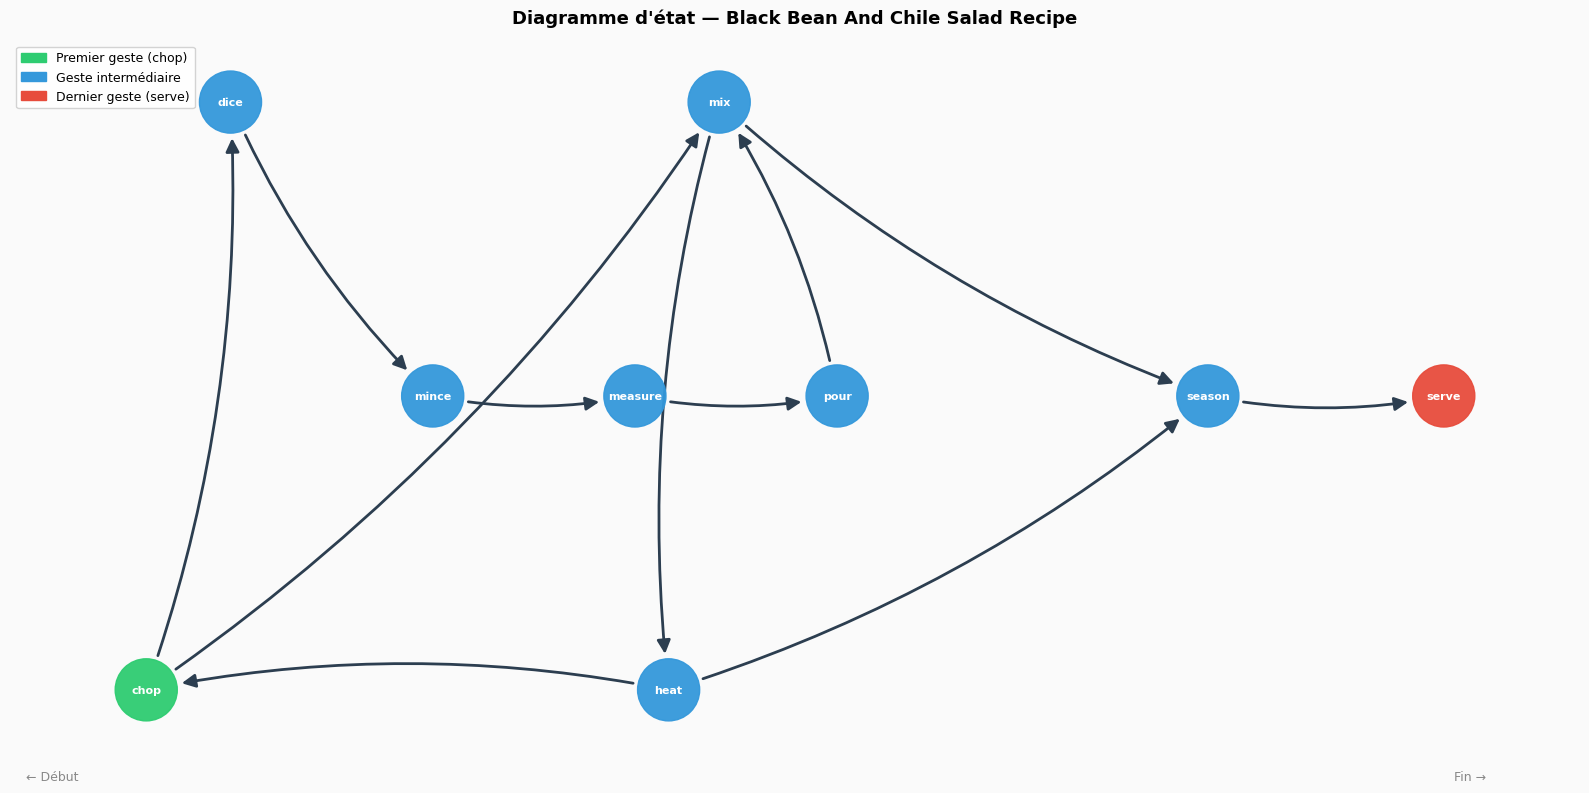

In [ ]:
# ── Cellule 3.5 : Diagramme d'état d'une recette
# Bulles reliées par des flèches selon l'ordre des gestes dans la recette.
# Position x = ordre moyen du geste dans les 3 variantes (gauche = début, droite = fin).
# Pas de pourcentages — juste les transitions.

import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from collections import Counter, defaultdict

SEUIL_PROB = 0.3   # filtrer les transitions rares (ajustable)

def build_graph(row, seuil=SEUIL_PROB):
    transitions = Counter()
    out_counts  = Counter()
    for col in ['actions_principale', 'actions_ingredients', 'actions_permutation']:
        seq = row[col]
        if not isinstance(seq, list) or len(seq) < 2:
            continue
        for a, b in zip(seq[:-1], seq[1:]):
            transitions[(a, b)] += 1
            out_counts[a] += 1
    G = nx.DiGraph()
    for (a, b), count in transitions.items():
        prob = count / out_counts[a]
        if prob >= seuil:
            G.add_edge(a, b)
    return G

def sequence_layout(G, row):
    """x = position moyenne dans la séquence, y distribué pour éviter la superposition."""
    pos_lists = defaultdict(list)
    for col in ['actions_principale', 'actions_ingredients', 'actions_permutation']:
        seq = row[col]
        if not isinstance(seq, list) or len(seq) == 0:
            continue
        n = len(seq)
        for i, action in enumerate(seq):
            if action in G.nodes():
                pos_lists[action].append(i / max(n - 1, 1))

    x_avg = {node: np.mean(vals) if vals else 0.5
              for node, vals in pos_lists.items()}

    # Regrouper les nœuds par position x proche et distribuer les y
    buckets = defaultdict(list)
    for node, x in x_avg.items():
        buckets[round(x, 1)].append(node)

    pos = {}
    for x_key, nodes in buckets.items():
        for j, node in enumerate(sorted(nodes)):
            y = j - (len(nodes) - 1) / 2
            pos[node] = (x_avg[node], y * 1.2)
    return pos

def draw_state_diagram(row, titre='', seuil=SEUIL_PROB):
    G = build_graph(row, seuil=seuil)
    if len(G.nodes) == 0:
        print('Aucun nœud. Essaie un seuil plus bas.')
        return

    pos = sequence_layout(G, row)

    # Identifier premier et dernier geste de la variante principale
    seq_principale = row['actions_principale']
    premier = seq_principale[0] if isinstance(seq_principale, list) and seq_principale else None
    dernier = seq_principale[-1] if isinstance(seq_principale, list) and seq_principale else None

    couleurs = []
    for node in G.nodes():
        if node == premier:
            couleurs.append('#2ECC71')
        elif node == dernier:
            couleurs.append('#E74C3C')
        else:
            couleurs.append('#3498DB')

    fig, ax = plt.subplots(figsize=(16, 8))
    fig.patch.set_facecolor('#FAFAFA')
    ax.set_facecolor('#FAFAFA')

    nx.draw_networkx_nodes(G, pos, node_color=couleurs,
                           node_size=2000, alpha=0.95, ax=ax)
    nx.draw_networkx_labels(G, pos, font_size=8, font_weight='bold',
                            font_color='white', ax=ax)
    nx.draw_networkx_edges(G, pos, edge_color='#2C3E50', arrows=True,
                           arrowsize=20, width=2,
                           min_source_margin=26, min_target_margin=26,
                           connectionstyle='arc3,rad=0.1', ax=ax)

    legende = [
        mpatches.Patch(color='#2ECC71', label=f'Premier geste ({premier})'),
        mpatches.Patch(color='#3498DB', label='Geste intermédiaire'),
        mpatches.Patch(color='#E74C3C', label=f'Dernier geste ({dernier})'),
    ]
    ax.legend(handles=legende, loc='upper left', fontsize=9, framealpha=0.85)

    # Repère temporel
    ax.annotate('← Début', xy=(0.01, -0.04), xycoords='axes fraction',
                fontsize=9, color='#888')
    ax.annotate('Fin →', xy=(0.92, -0.04), xycoords='axes fraction',
                fontsize=9, color='#888')

    ax.set_title(f'Diagramme d\'état — {titre}', fontsize=13, fontweight='bold', pad=12)
    ax.axis('off')
    plt.tight_layout()
    plt.show()

# ── Test sur la recette du Cellule 3 ─────────────────────────────────────────
row_viz = df[df['id'] == TEST_ID].iloc[0]
titre   = str(row_viz.get('title', TEST_ID)) if hasattr(row_viz, 'get') else str(TEST_ID)
draw_state_diagram(row_viz, titre=titre)


Exemple de la represente graphique d'une recette avec ses trois variantes. 

In [ ]:
# ── Cellule 4 : Reconnaissance Top-K + Post-traitement
def reconnaître_recette(observed: list, df: pd.DataFrame,
                        trie: RecipeTrie,
                        top_k: int = 5,
                        cluster_filter: int = None) -> dict:
    """
    Identifie les top_k recettes les plus probables pour une séquence observée.
    Inclut le post-traitement : détection d'ambiguïté, explications.
    """

    # ── Étape 1 : Filtrage via Trie
    if observed:
        # Essai 1 : préfixe complet → candidats qui ont exactement ce chemin
        candidate_ids = trie.search_prefix(observed)

        # Fallback 1 : Fuzzy matching Word2Vec 
        if len(candidate_ids) < top_k and 'fuzzy_search_trie' in dir():
            if len(candidate_ids) < top_k:
                candidate_ids, _, corrections = fuzzy_search_trie(observed, trie, glove_model)
            if corrections:
                for orig, corr, sim in corrections:
                    print(f'  [Fuzzy] "{orig}" → "{corr}" (sim={sim})')

        # Fallback 2 : 1er geste seulement
        if len(candidate_ids) < top_k:
            candidate_ids = trie.search_prefix([observed[0]])

        # Fallback 3 : toutes les recettes 
        if len(candidate_ids) < top_k:
            candidate_ids = set(df['id'])
    else:
        candidate_ids = set(df['id'])

    # ── Étape 2 : Pré-filtre par cluster
    if cluster_filter is not None:
        filtered = candidate_ids & set(df.loc[df['cluster'] == cluster_filter, 'id'])
        if len(filtered) >= top_k:
            candidate_ids = filtered

    candidates = df[df['id'].isin(candidate_ids)].copy()

    # ── Étape 3 : Scoring multi-critères
    results = []
    for _, row in candidates.iterrows():
        sc = score_recipe(observed, row)
        results.append({
            'id'        : row['id'],
            'name'      : row.get('title', row['id']),
            'cluster'   : row['cluster'],
            'score'     : sc['score'],
            'coverage'  : round(sc['cov'],  3),
            'position'  : round(sc['pos'],  3),
            'completion': round(sc['comp'], 3),
            'variante'  : sc['variante']
        })

    result_df = pd.DataFrame(results).sort_values('score', ascending=False).head(top_k).reset_index(drop=True)

    # ── Post-traitement 1 : Niveau de confiance
    def confiance(s):
        if s >= 0.8: return 'HAUTE'
        if s >= 0.5: return 'MOYENNE'
        return 'FAIBLE'
    result_df['confiance'] = result_df['score'].apply(confiance)
    result_df['score']     = result_df['score'].round(4)

    # ── Post-traitement 2 : Détection d'ambiguïté
    ambiguite = False
    raison_ambiguite = None
    if len(result_df) >= 2:
        ecart = result_df['score'].iloc[0] - result_df['score'].iloc[1]
        if ecart < 0.03:
            ambiguite = True
            raison_ambiguite = (
                f"Écart top-1/top-2 trop faible ({ecart:.4f}) — "
                f"{result_df['name'].iloc[0]} vs {result_df['name'].iloc[1]}"
            )

    # ── Post-traitement 3 : Génération d'explications
    def expliquer(row):
        parties = []
        if row['coverage']   == 1.0: parties.append('tous les gestes présents')
        elif row['coverage'] >= 0.7: parties.append('la plupart des gestes présents')
        else:                        parties.append('gestes partiellement présents')

        if row['position']   == 1.0: parties.append('ordre respecté')
        elif row['position'] >= 0.7: parties.append('ordre approximatif')
        else:                        parties.append('ordre non respecté')

        comp = row['completion']
        if   comp >= 0.8: parties.append('recette presque terminée')
        elif comp >= 0.4: parties.append('en cours de recette')
        else:             parties.append('début de recette')

        return ' | '.join(parties)

    result_df['explication'] = result_df.apply(expliquer, axis=1)

    return {
        'resultats'   : result_df,
        'ambiguite'   : ambiguite,
        'raison'      : raison_ambiguite,
        'nb_candidats': len(candidates)
    }
# ── Test de reconnaissance — gestes depuis une vraie recette
import random
random.seed(42)
recette_test    = df[df['id'] == TEST_ID].iloc[0]
seq_test        = recette_test['actions_principale']
nb_gestes       = random.randint(3, min(6, len(seq_test)))
indices         = sorted(random.sample(range(len(seq_test)), nb_gestes))
gestes_observes = [seq_test[j] for j in indices]
print('  ====== TEST DE RECONNAISSANCE')
print(f'\nGestes observés : {gestes_observes}  ({nb_gestes} gestes)')
print()

res    = reconnaître_recette(gestes_observes, df, trie, top_k=5)
df_res = res['resultats']

print(df_res[['id', 'name', 'cluster', 'score', 'confiance']].to_string(index=False))
print()
print('── Explications ──')
for _, row in df_res.iterrows():
    print(f"  {row['name'][:35]:<35} → {row['explication']}")
print()
print(f"Candidats filtrés par Trie : {res['nb_candidats']:,}")

if res['ambiguite']:
    print(f"\nAMBIGUÏTÉ DÉTECTÉE : {res['raison']}")
else:
    top1 = df_res.iloc[0]
    print(f"\nRecette identifiée : {top1['name']}  (score={top1['score']}, confiance={top1['confiance']})")

true_id = recette_test['id']
if true_id in df_res['id'].values:
    rang = df_res[df_res['id'] == true_id].index[0] + 1
    print(f"Vraie recette trouvée au rang {rang} ")
else:
    print(f"Vraie recette absente du Top-5 ")


  ====== TEST DE RECONNAISSANCE

Gestes observés : ['chop', 'mix', 'heat', 'season', 'serve']  (5 gestes)

        id                                      name  cluster  score confiance
16a9d7c7de         Black Bean And Chile Salad Recipe       20    1.0     HAUTE
9f6d0187d3                                Bean Salad       20    1.0     HAUTE
9291d25423                              Cabbage Soup       20    1.0     HAUTE
92998b3603                    Roasted Corn Guacamole       20    1.0     HAUTE
929f0066d5 sig's Lentil,Tomato, Zatar and Feta Salad       20    1.0     HAUTE

── Explications ──
  Black Bean And Chile Salad Recipe   → tous les gestes présents | ordre respecté | recette presque terminée
  Bean Salad                          → tous les gestes présents | ordre respecté | recette presque terminée
  Cabbage Soup                        → tous les gestes présents | ordre respecté | recette presque terminée
  Roasted Corn Guacamole              → tous les gestes présents | ordre

Séquence Observee : 10 gestes disponibles
════════════════════════════════════════════════════════════
Geste 1 : +chop         → Top1 = Asparagus Salsa                 score=1.0000  HAUTE
Ambiguïté : Écart top-1/top-2 trop faible (0.0000) — Asparagus Salsa vs Chicken Salad With Blue Cheese
Geste 2 : +heat         → Top1 = Curried Cabbage                 score=1.0000  HAUTE
Ambiguïté : Écart top-1/top-2 trop faible (0.0000) — Curried Cabbage vs Peppered Ulster Pork
Geste 3 : +brown        → Top1 = Provencal Chicken Stew          score=0.9538  HAUTE
Ambiguïté : Écart top-1/top-2 trop faible (0.0038) — Provencal Chicken Stew vs Chicken & Broccoli
Geste 4 : +saute        → Top1 = Dominican Sancocho              score=0.9600  HAUTE
Ambiguïté : Écart top-1/top-2 trop faible (0.0200) — Dominican Sancocho vs Creamy Mushroom Chicken
Geste 5 : +stir         → Top1 = caper stuffed veal              score=0.9833  HAUTE
Ambiguïté : Écart top-1/top-2 trop faible (0.0197) — caper stuffed veal vs Beef

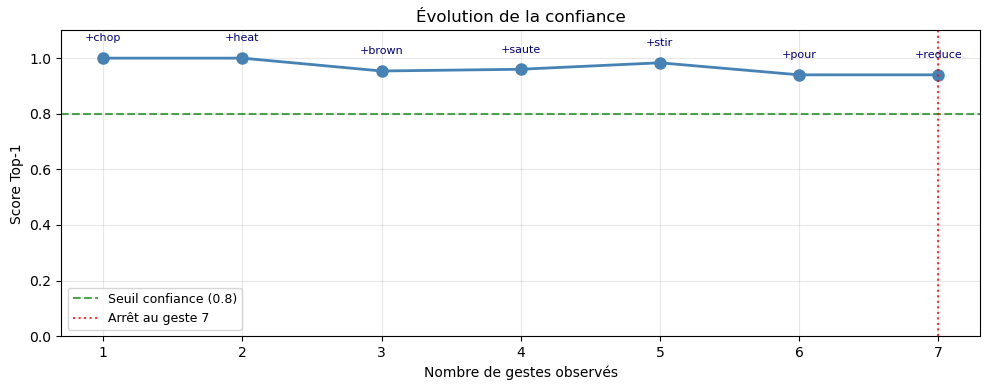


  Recette suggérée
═══════════════════════════════════════════════════════
  Titre    : Beef and Green Tomato Casserole Recipe
  ID       : 7fd7a3336e
  Score    : 0.94
  Confiance: HAUTE
  Gestes utilisés : 7 / 10
═══════════════════════════════════════════════════════

  VRAIE RECETTE
═══════════════════════════════════════════════════════
  Titre    : Beef and Green Tomato Casserole Recipe
  ID       : 7fd7a3336e
  Résultat : CORRECT
═══════════════════════════════════════════════════════


In [7]:
# ── Cellule 5 : Démonstration — reconnaissance progressive avec arrêt dynamique
import matplotlib.pyplot as plt
import random
import os
os.makedirs('img', exist_ok=True)

# ── Paramètres d'arrêt dynamique
SEUIL_SCORE    = 0.8   # confiance HAUTE
SEUIL_ECART    = 0.03  # écart min top-1/top-2 pour éviter l'ambiguïté
MIN_GESTES     = 2     # nombre minimum de gestes avant d'autoriser l'arrêt

# Choisir une recette secrète au hasard
random.seed(42)  # résultats stables
recette_secrete   = df.sample(1, random_state=42).iloc[0]
sequence_observer = recette_secrete['actions_principale']

print(f'Séquence Observee : {len(sequence_observer)} gestes disponibles')
print('═' * 60)

all_steps = []
arret_idx = None

for nb_gestes in range(1, len(sequence_observer) + 1):
    observed = sequence_observer[:nb_gestes]
    res  = reconnaître_recette(observed, df, trie, top_k=3)
    top3 = res['resultats']

    top1_score = top3['score'].iloc[0]
    top1_name  = top3['name'].iloc[0]
    top1_id    = top3['id'].iloc[0]
    confiance  = top3['confiance'].iloc[0]

    # Calcul de l'écart top-1 / top-2
    ecart = top1_score - top3['score'].iloc[1] if len(top3) > 1 else 1.0

    print(f'Geste {nb_gestes} : +{observed[-1]:<12} → Top1 = {top1_name[:30]:<30}  score={top1_score:.4f}  {confiance}')
    if res['ambiguite']:
        print(f'Ambiguïté : {res["raison"]}')

    all_steps.append({
        'nb_gestes' : nb_gestes,
        'observed'  : list(observed),
        'top1_name' : top1_name,
        'top1_id'   : top1_id,
        'top1_score': top1_score,
        'confiance' : confiance,
        'ecart'     : ecart
    })

    # ── Condition d'arrêt dynamique
    if nb_gestes >= MIN_GESTES and top1_score >= SEUIL_SCORE and ecart >= SEUIL_ECART:
        arret_idx = nb_gestes
        print(f'\n→ Condition remplie au geste {nb_gestes} : score={top1_score:.4f}, écart={ecart:.4f}')
        print(f'→ Arrêt anticipé — recette identifiée avec confiance HAUTE.')
        break

if arret_idx is None:
    print(f'\n→ Arrêt après tous les gestes ({len(sequence_observer)}) — confiance jamais atteinte.')

# ── Graphique : évolution du score top-1
fig, ax = plt.subplots(figsize=(10, 4))

steps  = [s['nb_gestes'] for s in all_steps]
scores = [s['top1_score'] for s in all_steps]
labels = [s['observed'][-1] for s in all_steps]

ax.plot(steps, scores, marker='o', color='steelblue', linewidth=2, markersize=8)
for x, y, lbl in zip(steps, scores, labels):
    ax.annotate(f'+{lbl}', xy=(x, y), xytext=(0, 12),
                textcoords='offset points', ha='center', fontsize=8, color='navy')

ax.axhline(SEUIL_SCORE, color='green', linestyle='--', alpha=0.7, label=f'Seuil confiance ({SEUIL_SCORE})')

if arret_idx:
    ax.axvline(arret_idx, color='red', linestyle=':', alpha=0.8, label=f'Arrêt au geste {arret_idx}')

ax.set_xlabel('Nombre de gestes observés')
ax.set_ylabel('Score Top-1')
ax.set_title('Évolution de la confiance')
ax.set_xticks(steps)
ax.set_ylim(0, 1.1)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('img/strategie1_progression.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Résultat final
dernier = all_steps[-1]
print()
print('  Recette suggérée')
print('═' * 55)
print(f"  Titre    : {dernier['top1_name']}")
print(f"  ID       : {dernier['top1_id']}")
print(f"  Score    : {dernier['top1_score']}")
print(f"  Confiance: {dernier['confiance']}")
print(f"  Gestes utilisés : {dernier['nb_gestes']} / {len(sequence_observer)}")
print('═' * 55)
print()
print('  VRAIE RECETTE')
print('═' * 55)
print(f"  Titre    : {recette_secrete['title']}")
print(f"  ID       : {recette_secrete['id']}")
correct = dernier['top1_id'] == recette_secrete['id']
print(f"  Résultat : {'CORRECT' if correct else 'INCORRECT'}")
print('═' * 55)


══════════════════════════════════════════════════════════════════════
  SWEEP PERFORMANCE — 200 recettes, top_k=5
══════════════════════════════════════════════════════════════════════

  Gestes   N valid         Top-1      Top-5    Score moy
  ────────────────────────────────────────────────────────
  3        200            13.0%     27.5%       0.9761
  4        193            26.4%     43.0%       0.9746
  5        168            39.3%     69.6%       0.9759
  6        110            67.3%     87.3%       0.9778


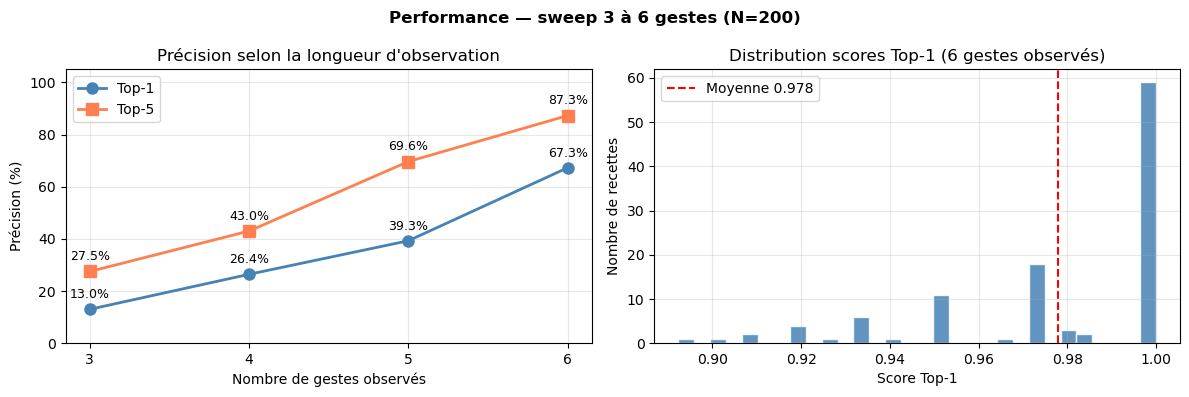

In [ ]:
# ── Cellule 6 : Analyse de performance — sweep sur longueur d'observation 
# Teste le système sur le même échantillon de 200 recettes
# avec 3, 4, 5 et 6 gestes observés pour voir la courbe de progression
# Mesure : Top-1, Top-5, score moyen

import random
import matplotlib.pyplot as plt

random.seed(42)
N_SAMPLE    = 200
TOP_K       = 5
LONGUEURS   = [3, 4, 5, 6]

sample = df.sample(n=N_SAMPLE, random_state=42)
resultats_perf = {}

for NB_GESTES in LONGUEURS:
    top1_hits = 0
    top5_hits = 0
    scores_list = []

    for _, row in sample.iterrows():
        true_id = row['id']
        seq = row['actions_principale']
        if not seq or len(seq) < NB_GESTES:
            continue

        observed = seq[:NB_GESTES]
        results = reconnaître_recette(observed, df, trie, top_k=TOP_K)['resultats']

        if not results.empty:
            scores_list.append(results['score'].iloc[0])
            if results['id'].iloc[0] == true_id:
                top1_hits += 1
            if true_id in results['id'].values:
                top5_hits += 1

    n_valid = len(scores_list)
    resultats_perf[NB_GESTES] = {
        'top1': top1_hits,
        'top5': top5_hits,
        'n_valid': n_valid,
        'scores': scores_list
    }

# ── Affichage tabulaire
print('═' * 70)
print(f'  SWEEP PERFORMANCE — {N_SAMPLE} recettes, top_k={TOP_K}')
print('═' * 70)
print(f'\n  {"Gestes":<8} {"N valid":<10} {"Top-1":>10} {"Top-5":>10} {"Score moy":>12}')
print('  ' + '─' * 56)
for nb in LONGUEURS:
    d = resultats_perf[nb]
    n = d['n_valid']
    print(f'  {nb:<8} {n:<10} '
          f'{d["top1"]/n*100:>8.1f}% '
          f'{d["top5"]/n*100:>8.1f}% '
          f'{np.mean(d["scores"]):>12.4f}')

# ── Graphique : courbe de précision
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

top1_vals = [resultats_perf[nb]['top1'] / resultats_perf[nb]['n_valid'] * 100 for nb in LONGUEURS]
top5_vals = [resultats_perf[nb]['top5'] / resultats_perf[nb]['n_valid'] * 100 for nb in LONGUEURS]

axes[0].plot(LONGUEURS, top1_vals, 'o-', label='Top-1', color='steelblue', linewidth=2, markersize=8)
axes[0].plot(LONGUEURS, top5_vals, 's-', label='Top-5', color='coral', linewidth=2, markersize=8)
for x, y in zip(LONGUEURS, top1_vals):
    axes[0].annotate(f'{y:.1f}%', xy=(x, y), xytext=(0, 8), textcoords='offset points', ha='center', fontsize=9)
for x, y in zip(LONGUEURS, top5_vals):
    axes[0].annotate(f'{y:.1f}%', xy=(x, y), xytext=(0, 8), textcoords='offset points', ha='center', fontsize=9)
axes[0].set_xlabel('Nombre de gestes observés')
axes[0].set_ylabel('Précision (%)')
axes[0].set_title('Précision selon la longueur d\'observation')
axes[0].set_xticks(LONGUEURS)
axes[0].set_ylim(0, 105)
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# Histogramme des scores top-1 pour la dernière longueur
dernier = LONGUEURS[-1]
axes[1].hist(resultats_perf[dernier]['scores'], bins=30, color='steelblue',
             edgecolor='white', alpha=0.85)
axes[1].axvline(np.mean(resultats_perf[dernier]['scores']), color='red',
                linestyle='--', label=f'Moyenne {np.mean(resultats_perf[dernier]["scores"]):.3f}')
axes[1].set_xlabel('Score Top-1')
axes[1].set_ylabel('Nombre de recettes')
axes[1].set_title(f'Distribution scores Top-1 ({dernier} gestes observés)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle(f'Performance — sweep 3 à 6 gestes (N={N_SAMPLE})', fontweight='bold')
plt.tight_layout()
plt.savefig('img/strategie1_performance.png', dpi=150, bbox_inches='tight')
plt.show()

════════════════════════════════════════════════════════════════════════════════
  SWEEP FILTRE CLUSTER — 200 recettes, K=25 clusters
════════════════════════════════════════════════════════════════════════════════

  Gestes   Mode                    Top-1      Top-5        Temps
  ──────────────────────────────────────────────────────────────────
  3        sans_filtre            10.5%     26.5%      78.95 ms
  3        avec_filtre            18.0%     39.0%      11.39 ms
  ──────────────────────────────────────────────────────────────────
  4        sans_filtre            25.6%     43.1%     181.62 ms
  4        avec_filtre            35.4%     54.4%      19.47 ms
  ──────────────────────────────────────────────────────────────────
  5        sans_filtre            45.0%     63.1%     373.89 ms
  5        avec_filtre            48.8%     69.4%      26.88 ms
  ──────────────────────────────────────────────────────────────────
  6        sans_filtre            69.2%     84.6%     517.5

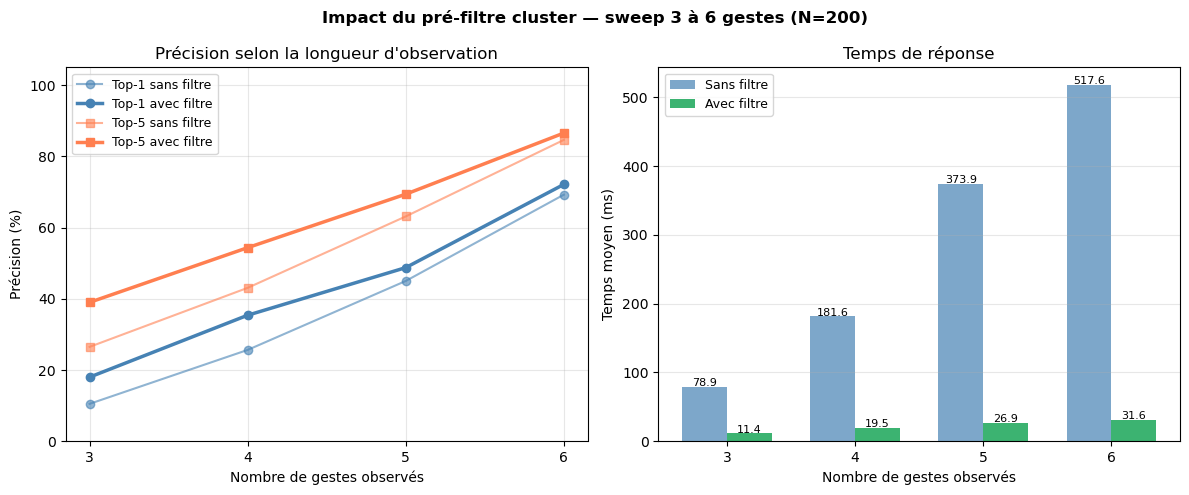


Sauvegardé : img/strategie1_filtre_cluster.png


In [ ]:
# ── Cellule 7 : Filtre cluster — sweep sur longueur d'observation 
# Compare AVEC vs SANS pré-filtre cluster
# sur 3, 4, 5 et 6 gestes observés (même échantillon 200 recettes)

import time
import matplotlib.pyplot as plt

N_TEST     = 200
LONGUEURS  = [3, 4, 5, 6]
sample2    = df.sample(n=N_TEST, random_state=99)

resultats_cl = {}

for NB_GESTES in LONGUEURS:
    res = {'sans_filtre': {'top1': 0, 'top5': 0, 'temps': []},
           'avec_filtre': {'top1': 0, 'top5': 0, 'temps': []}}
    n_valid = 0

    for _, row in sample2.iterrows():
        true_id = row['id']
        seq     = row['actions_principale']
        cluster = row['cluster']
        if not seq or len(seq) < NB_GESTES:
            continue
        observed = seq[:NB_GESTES]
        n_valid += 1

        # Sans pré-filtre cluster
        t0   = time.perf_counter()
        r_no = reconnaître_recette(observed, df, trie, top_k=5)['resultats']
        res['sans_filtre']['temps'].append(time.perf_counter() - t0)
        if not r_no.empty:
            if r_no['id'].iloc[0] == true_id: res['sans_filtre']['top1'] += 1
            if true_id in r_no['id'].values:  res['sans_filtre']['top5'] += 1

        # Avec pré-filtre cluster
        t0   = time.perf_counter()
        r_cl = reconnaître_recette(observed, df, trie, top_k=5, cluster_filter=cluster)['resultats']
        res['avec_filtre']['temps'].append(time.perf_counter() - t0)
        if not r_cl.empty:
            if r_cl['id'].iloc[0] == true_id: res['avec_filtre']['top1'] += 1
            if true_id in r_cl['id'].values:  res['avec_filtre']['top5'] += 1

    resultats_cl[NB_GESTES] = {'res': res, 'n_valid': n_valid}

# ── Affichage tabulaire 
print('═' * 80)
print(f'  SWEEP FILTRE CLUSTER — {N_TEST} recettes, K=25 clusters')
print('═' * 80)
print(f'\n  {"Gestes":<8} {"Mode":<18} {"Top-1":>10} {"Top-5":>10} {"Temps":>12}')
print('  ' + '─' * 66)
for nb in LONGUEURS:
    d = resultats_cl[nb]['res']
    n = resultats_cl[nb]['n_valid']
    for label in ('sans_filtre', 'avec_filtre'):
        d2 = d[label]
        moy_ms = np.mean(d2['temps']) * 1000
        print(f'  {nb:<8} {label:<18} '
              f'{d2["top1"]/n*100:>8.1f}% '
              f'{d2["top5"]/n*100:>8.1f}% '
              f'{moy_ms:>10.2f} ms')
    print('  ' + '─' * 66)

# ── Graphiques 
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

top1_sans = [resultats_cl[nb]['res']['sans_filtre']['top1'] / resultats_cl[nb]['n_valid'] * 100 for nb in LONGUEURS]
top1_avec = [resultats_cl[nb]['res']['avec_filtre']['top1'] / resultats_cl[nb]['n_valid'] * 100 for nb in LONGUEURS]
top5_sans = [resultats_cl[nb]['res']['sans_filtre']['top5'] / resultats_cl[nb]['n_valid'] * 100 for nb in LONGUEURS]
top5_avec = [resultats_cl[nb]['res']['avec_filtre']['top5'] / resultats_cl[nb]['n_valid'] * 100 for nb in LONGUEURS]

# Graphique 1 : précision selon nb gestes
axes[0].plot(LONGUEURS, top1_sans, 'o-', label='Top-1 sans filtre', color='steelblue', alpha=0.6)
axes[0].plot(LONGUEURS, top1_avec, 'o-', label='Top-1 avec filtre', color='steelblue', linewidth=2.5)
axes[0].plot(LONGUEURS, top5_sans, 's-', label='Top-5 sans filtre', color='coral', alpha=0.6)
axes[0].plot(LONGUEURS, top5_avec, 's-', label='Top-5 avec filtre', color='coral', linewidth=2.5)
axes[0].set_xlabel('Nombre de gestes observés')
axes[0].set_ylabel('Précision (%)')
axes[0].set_title('Précision selon la longueur d\'observation')
axes[0].set_xticks(LONGUEURS)
axes[0].set_ylim(0, 105)
axes[0].grid(True, alpha=0.3)
axes[0].legend(fontsize=9)

# Graphique 2 : temps moyen
temps_sans = [np.mean(resultats_cl[nb]['res']['sans_filtre']['temps']) * 1000 for nb in LONGUEURS]
temps_avec = [np.mean(resultats_cl[nb]['res']['avec_filtre']['temps']) * 1000 for nb in LONGUEURS]
x = np.arange(len(LONGUEURS))
w = 0.35
axes[1].bar(x - w/2, temps_sans, w, label='Sans filtre', color='steelblue', alpha=0.7)
axes[1].bar(x + w/2, temps_avec, w, label='Avec filtre', color='mediumseagreen')
axes[1].set_xticks(x)
axes[1].set_xticklabels(LONGUEURS)
axes[1].set_xlabel('Nombre de gestes observés')
axes[1].set_ylabel('Temps moyen (ms)')
axes[1].set_title('Temps de réponse')
axes[1].grid(True, alpha=0.3, axis='y')
axes[1].legend(fontsize=9)
for xi, (ts, ta) in enumerate(zip(temps_sans, temps_avec)):
    axes[1].text(xi - w/2, ts + 1, f'{ts:.1f}', ha='center', fontsize=8)
    axes[1].text(xi + w/2, ta + 1, f'{ta:.1f}', ha='center', fontsize=8)

plt.suptitle(f'Impact du pré-filtre cluster — sweep 3 à 6 gestes (N={N_TEST})',
             fontweight='bold')
plt.tight_layout()
plt.savefig('img/strategie1_filtre_cluster.png', dpi=150, bbox_inches='tight')
plt.show()
print('\nSauvegardé : img/strategie1_filtre_cluster.png')

Afin de faire un resume de cette etape ainsi que l'etape suivante, j'ai creer un rapport streamlit afin de regrouper les informations importantes. la strategie 2 n'a pas ete faite, pour trois raison: 

1- Faire un entrainement avec GNN demande des ressources que mon ordinateur ne peut pas prendre en charge 

2- La complexité de la tache

3- le temps de realiser la tache

C'est pour cela que j'ai decide de juste faire des entrainement supervisé.